In [1]:
!pip install numpy pandas scikit-learn matplotlib

Total timestamps: 5761

=== Generating Home Data ===

Home A data shape: (5761, 6)
Home A average consumption: 1.54 kWh

Home B data shape: (5761, 6)
Home B average consumption: 3.59 kWh

Home C data shape: (5761, 6)
Home C average consumption: 2.07 kWh

=== Injecting Anomalies ===
Injected 20 anomalies
Injected 20 anomalies
Injected 20 anomalies

=== Adding Features ===

Features after engineering:
['timestamp', 'consumption_kwh', 'hour', 'day_of_week', 'is_weekend', 'month', 'is_anomaly', 'lag_1', 'lag_4', 'lag_96', 'rolling_mean_4', 'rolling_mean_96', 'rolling_std_4']

=== Saved CSV Files ===
homes/home_a.csv
homes/home_b.csv
homes/home_c.csv


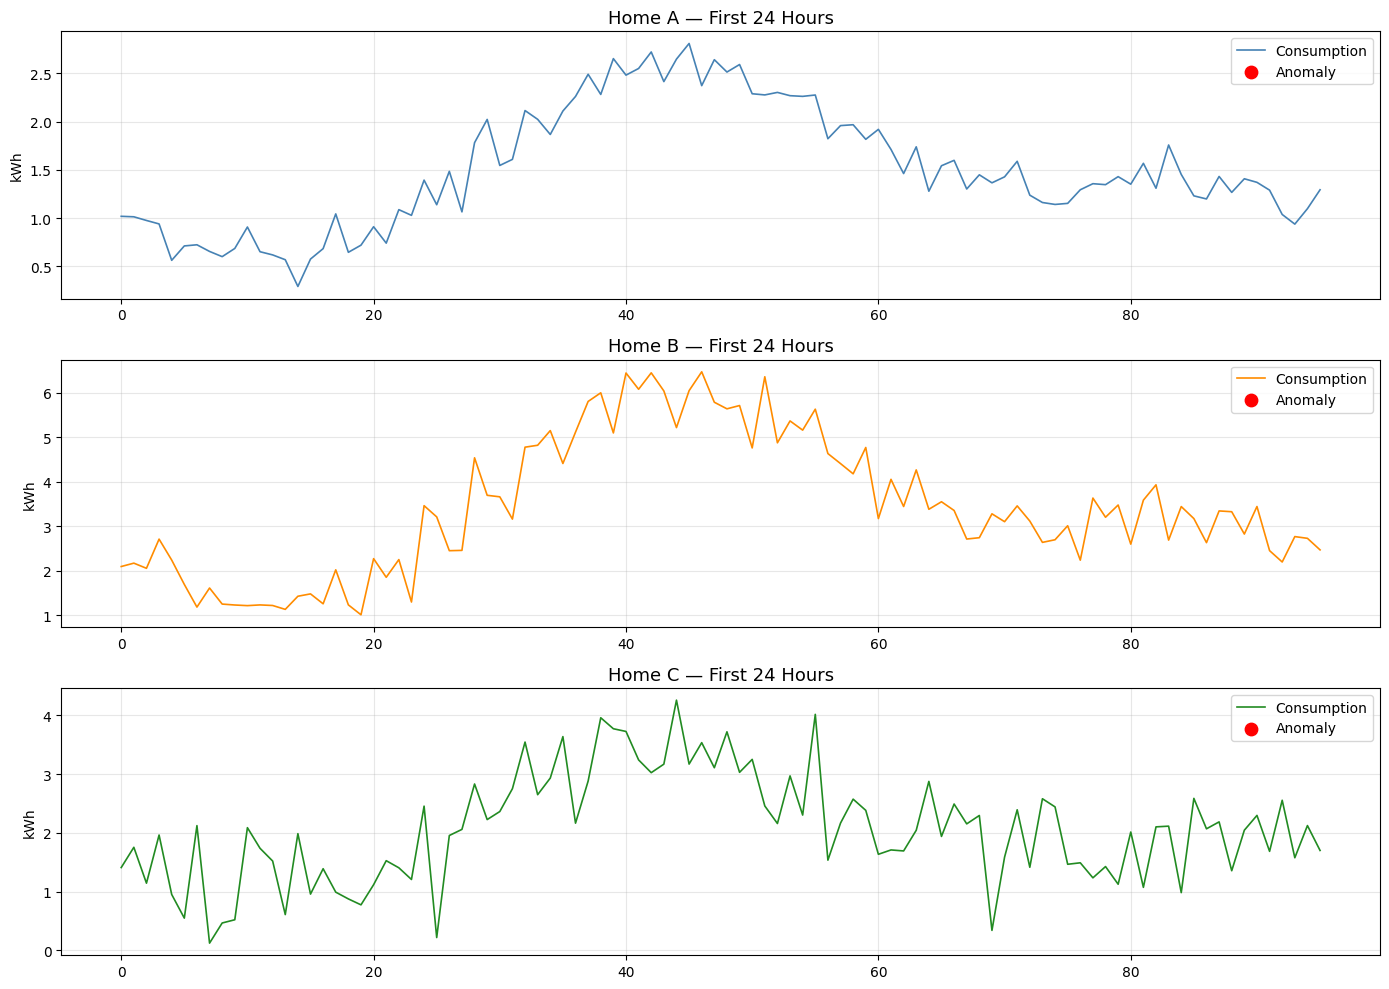


Chart saved: data_overview.png

✅ Data preparation complete!


In [4]:
# 01_data_preparation.py
# This file generates realistic energy consumption data for 3 virtual homes

import pandas as pd      # For data tables
import numpy as np       # For mathematics
import matplotlib.pyplot as plt  # For charts
import os                # For folder creation

# Set random seed - this makes our random data the same every run
# Without this, each run gives different numbers
np.random.seed(42)

# Create time range: timestamps every 15 minutes for 60 days
# pd.date_range creates a sequence of dates
timestamps = pd.date_range(
    start='2024-01-01',    # Start date
    end='2024-03-01',      # End date
    freq='15min'           # Every 15 minutes
)
print(f"Total timestamps: {len(timestamps)}")  # Should print ~5760

# ─── Understand energy patterns ───
# Real homes consume energy in patterns:
# - Low at night (people sleeping)
# - High in morning (breakfast, shower)
# - Medium in afternoon
# - High in evening (cooking, TV)

def generate_home_data(timestamps, base_load, noise_level, name):
    """
    Generate realistic energy consumption for ONE home.

    Parameters:
    - timestamps: when the measurements happen
    - base_load: average consumption (kWh)
    - noise_level: how variable the consumption is
    - name: home name (for printing)
    """
    data = []  # We'll collect each row here

    for ts in timestamps:
        hour = ts.hour        # 0-23
        day = ts.dayofweek    # 0=Monday ... 6=Sunday

        # ─── Hourly pattern ───
        # This creates a realistic daily curve using sine waves
        # np.sin creates a wave shape
        hourly_pattern = (
            0.5 * np.sin(2 * np.pi * (hour - 6) / 24) +   # morning peak
            0.3 * np.sin(2 * np.pi * (hour - 19) / 12) +  # evening peak
            1.0                                            # baseline offset
        )

        # ─── Weekend pattern ───
        # Weekends have different consumption patterns
        weekend_factor = 1.1 if day >= 5 else 1.0  # day >= 5 means Saturday or Sunday

        # ─── Calculate consumption ───
        # base_load: how much this home typically uses
        # hourly_pattern: multiplied by time-of-day factor
        # weekend_factor: multiplied by day factor
        # np.random.normal: adds realistic random variation
        consumption = (
            base_load * hourly_pattern * weekend_factor +
            np.random.normal(0, noise_level)  # random noise
        )

        # Energy can't be negative!
        consumption = max(0.1, consumption)

        data.append({
            'timestamp': ts,
            'consumption_kwh': round(consumption, 3),
            'hour': hour,
            'day_of_week': day,
            'is_weekend': int(day >= 5),
            'month': ts.month,
        })

    df = pd.DataFrame(data)
    print(f"\n{name} data shape: {df.shape}")
    print(f"{name} average consumption: {df['consumption_kwh'].mean():.2f} kWh")
    return df

# ─── Generate data for three homes ───
# Each home has different characteristics — this creates our Non-IID distribution
print("\n=== Generating Home Data ===")

# Home A: Small family, moderate consumption
df_a = generate_home_data(
    timestamps,
    base_load=1.5,    # moderate base
    noise_level=0.15, # low variability
    name="Home A"
)

# Home B: Large family, high consumption
df_b = generate_home_data(
    timestamps,
    base_load=3.5,    # high base
    noise_level=0.35, # more variable
    name="Home B"
)

# Home C: Single person, variable schedule
df_c = generate_home_data(
    timestamps,
    base_load=2.0,    # medium base
    noise_level=0.5,  # high variability
    name="Home C"
)

# ─── Inject anomalies ───
# We manually add some "unusual" consumption events
# These simulate faulty appliances, left-on devices, etc.
# We'll use these later to test anomaly detection

def inject_anomalies(df, n_anomalies=20):
    """
    Replace n random rows with unusually high consumption.
    Returns the DataFrame with anomaly labels.
    """
    df = df.copy()
    # Add a label column (0=normal, 1=anomaly)
    df['is_anomaly'] = 0

    # Pick random positions to inject anomalies
    # avoid first and last 100 rows (need them for lag features later)
    anomaly_indices = np.random.choice(
        df.index[100:-100],
        size=n_anomalies,
        replace=False
    )

    # Set those positions to very high consumption
    for idx in anomaly_indices:
        df.at[idx, 'consumption_kwh'] = np.random.uniform(8, 15)
        df.at[idx, 'is_anomaly'] = 1

    print(f"Injected {n_anomalies} anomalies")
    return df

print("\n=== Injecting Anomalies ===")
df_a = inject_anomalies(df_a)
df_b = inject_anomalies(df_b)
df_c = inject_anomalies(df_c)

# ─── Feature Engineering ───
# Raw data isn't enough for ML. We create additional features
# that help the model make better predictions.

def add_features(df):
    """
    Add time-based and lag features.
    Lag features: the value from N steps ago.
    Rolling features: averages over recent windows.
    These give the model context about recent history.
    """
    df = df.copy()
    df = df.sort_values('timestamp').reset_index(drop=True)

    # Lag features (what was consumption N periods ago)
    df['lag_1'] = df['consumption_kwh'].shift(1)    # 15 min ago
    df['lag_4'] = df['consumption_kwh'].shift(4)    # 1 hour ago
    df['lag_96'] = df['consumption_kwh'].shift(96)  # 24 hours ago

    # Rolling average (average over last N periods)
    df['rolling_mean_4'] = df['consumption_kwh'].rolling(4).mean()
    df['rolling_mean_96'] = df['consumption_kwh'].rolling(96).mean()

    # Rolling standard deviation (measures variability)
    df['rolling_std_4'] = df['consumption_kwh'].rolling(4).std()

    # Drop rows with NaN (lag creates NaN at the start)
    df = df.dropna().reset_index(drop=True)
    return df

print("\n=== Adding Features ===")
df_a = add_features(df_a)
df_b = add_features(df_b)
df_c = add_features(df_c)

print(f"\nFeatures after engineering:")
print(df_a.columns.tolist())

# ─── Save to CSV ───
os.makedirs('homes', exist_ok=True)
df_a.to_csv('homes/home_a.csv', index=False)
df_b.to_csv('homes/home_b.csv', index=False)
df_c.to_csv('homes/home_c.csv', index=False)

print("\n=== Saved CSV Files ===")
print("homes/home_a.csv")
print("homes/home_b.csv")
print("homes/home_c.csv")

# ─── Visualize the data ───
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, df, name, color in zip(
    axes,
    [df_a, df_b, df_c],
    ['Home A', 'Home B', 'Home C'],
    ['steelblue', 'darkorange', 'forestgreen']
):
    sample = df.head(96)  # First day
    ax.plot(sample.index, sample['consumption_kwh'],
            color=color, linewidth=1.2, label='Consumption')

    anomalies = sample[sample['is_anomaly'] == 1]
    ax.scatter(anomalies.index, anomalies['consumption_kwh'],
               color='red', s=80, zorder=5, label='Anomaly')

    ax.set_title(f'{name} — First 24 Hours', fontsize=13)
    ax.set_ylabel('kWh')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved: data_overview.png")
print("\n✅ Data preparation complete!")

In [5]:
# 02_ml_forecasting.py
# ─────────────────────────────────────────────
# Trains a Random Forest to predict next energy
# consumption value using historical features.
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle  # For saving/loading models
import os

os.makedirs('models', exist_ok=True)

# --- Check and Generate Data if Missing ---
data_files_exist = all(os.path.exists(f'homes/home_{home}.csv') for home in ['a', 'b', 'c'])

if not data_files_exist:
    print("⚠️ Data files not found. Regenerating data...")
    # Set seed for reproducibility
    np.random.seed(42)

    # Create time range: timestamps every 15 minutes for 60 days
    timestamps = pd.date_range(
        start='2024-01-01',
        end='2024-03-01',
        freq='15min'
    )

    def generate_home_data(timestamps, base_load, noise_level, name):
        data = []
        for ts in timestamps:
            hour = ts.hour
            day = ts.dayofweek
            hourly_pattern = (
                0.5 * np.sin(2 * np.pi * (hour - 6) / 24) +
                0.3 * np.sin(2 * np.pi * (hour - 19) / 12) +
                1.0
            )
            weekend_factor = 1.1 if day >= 5 else 1.0
            consumption = (
                base_load * hourly_pattern * weekend_factor +
                np.random.normal(0, noise_level)
            )
            consumption = max(0.1, consumption)
            data.append({
                'timestamp': ts,
                'consumption_kwh': round(consumption, 3),
                'hour': hour,
                'day_of_week': day,
                'is_weekend': int(day >= 5),
                'month': ts.month,
            })
        df = pd.DataFrame(data)
        return df

    def inject_anomalies(df, n_anomalies=20):
        df = df.copy()
        df['is_anomaly'] = 0
        anomaly_indices = np.random.choice(
            df.index[100:-100],
            size=n_anomalies,
            replace=False
        )
        for idx in anomaly_indices:
            df.at[idx, 'consumption_kwh'] = np.random.uniform(8, 15)
            df.at[idx, 'is_anomaly'] = 1
        return df

    def add_features(df):
        df = df.copy().sort_values('timestamp').reset_index(drop=True)
        df['lag_1'] = df['consumption_kwh'].shift(1)
        df['lag_4'] = df['consumption_kwh'].shift(4)
        df['lag_96'] = df['consumption_kwh'].shift(96)
        df['rolling_mean_4'] = df['consumption_kwh'].rolling(4).mean()
        df['rolling_mean_96'] = df['consumption_kwh'].rolling(96).mean()
        df['rolling_std_4'] = df['consumption_kwh'].rolling(4).std()
        df = df.dropna().reset_index(drop=True)
        return df

    # Generate data for three homes
    df_a = generate_home_data(timestamps, base_load=1.5, noise_level=0.15, name="Home A")
    df_b = generate_home_data(timestamps, base_load=3.5, noise_level=0.35, name="Home B")
    df_c = generate_home_data(timestamps, base_load=2.0, noise_level=0.50, name="Home C")

    # Inject Anomalies
    df_a = inject_anomalies(df_a)
    df_b = inject_anomalies(df_b)
    df_c = inject_anomalies(df_c)

    # Feature Engineering
    df_a = add_features(df_a)
    df_b = add_features(df_b)
    df_c = add_features(df_c)

    # Save to CSV
    os.makedirs('homes', exist_ok=True)
    df_a.to_csv('homes/home_a.csv', index=False)
    df_b.to_csv('homes/home_b.csv', index=False)
    df_c.to_csv('homes/home_c.csv', index=False)
    print("✅ Data regenerated and saved to 'homes/' folder.")

# ── Define which columns are features ─────────
# These are the inputs we give to the model.
FEATURE_COLUMNS = [
    'lag_1',  # Consumption 15 min ago
    'lag_4',  # Consumption 1 hour ago
    'lag_96', # Consumption 24 hours ago
    'rolling_mean_4',  # Average over last hour
    'rolling_mean_96', # Average over last day
    'rolling_std_4', # Variability over last hour
    'hour',  # Hour of day (0-23)
    'day_of_week',  # Day (0=Mon ... 6=Sun)
    'is_weekend',  # 1 if weekend, 0 if weekday
    'month',  # Month (1-12)
]

# The target is what we want to predict
TARGET_COLUMN = 'consumption_kwh'

def train_model(home_name, filepath):
    """
    Train a Random Forest for one home.
    Returns the model and its evaluation metrics.
    """
    print(f"\n{'='*50}")
    print(f"Training model for {home_name}")
    print('='*50)

    # ── Load data ──────────────────────────────
    df = pd.read_csv(filepath, parse_dates=['timestamp'])
    print(f"Data loaded: {len(df)} rows")

    # ── Separate features and target ──────────
    X = df[FEATURE_COLUMNS].values  # Feature matrix (2D array)
    y = df[TARGET_COLUMN].values    # Target vector (1D array)
    print(f"Feature matrix shape: {X.shape}")  # (rows, features)
    print(f"Target vector shape: {y.shape}")  # (rows,)

    # ── Train/Test Split ───────────────────────
    # IMPORTANT: We use TIME-BASED split, not random split.
    # Why? Because energy data is sequential.
    # Using random split would let the model "see the future"
    # which is data leakage.
    #
    # 80% of data for training, 20% for testing.
    split_idx = int(len(df) * 0.8)
    X_train = X[:split_idx]  # First 80%
    X_test = X[split_idx:]   # Last 20%
    y_train = y[:split_idx]
    y_test = y[split_idx:]

    print(f"Training samples: {len(X_train)}")
    print(f"Testing samples: {len(X_test)}")

    # ── Create and Train Model ─────────────────
    model = RandomForestRegressor(
        n_estimators=100,  # Number of trees in the forest
        max_depth=10,      # Maximum depth of each tree
        random_state=42,   # For reproducibility
        n_jobs=-1          # Use all CPU cores
    )
    print("\nTraining... (this takes a few seconds)")
    model.fit(X_train, y_train)  # ← THIS IS LEARNING
    print("Training complete!")

    # ── Make Predictions ───────────────────────
    y_pred_train = model.predict(X_train)  # On training data
    y_pred_test = model.predict(X_test)    # On NEW test data

    # ── Calculate Errors ───────────────────────
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    print(f"\nResults for {home_name}:")
    print(f"  Train MAE: {train_mae:.4f} kWh")
    print(f"  Test MAE: {test_mae:.4f} kWh ← This is what matters")
    print(f"  Train RMSE: {train_rmse:.4f} kWh")
    print(f"  Test RMSE: {test_rmse:.4f} kWh")

    # ── Check for Overfitting ──────────────────
    # If train MAE << test MAE, model is overfitting.
    if train_mae < test_mae * 0.5:
        print("  ⚠ WARNING: Possible overfitting detected")
    else:
        print("  ✓ No significant overfitting")

    # ── Feature Importance ─────────────────────
    # Random Forest tells us which features matter most.
    importance = pd.DataFrame({
        'feature': FEATURE_COLUMNS,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\nTop 5 important features for {home_name}:")
    for _, row in importance.head(5).iterrows():
        bar = '█' * int(row['importance'] * 50)
        print(f"  {row['feature']:20s} {bar} {row['importance']:.3f}")

    # ── Save Model ─────────────────────────────
    model_path = f'models/model_{home_name[-1].lower()}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"\nModel saved: {model_path}")

    # ── Visualize Predictions ──────────────────
    # Show actual vs predicted for last 200 test points
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(y_test[-200:], label='Actual', color='steelblue', lw=1.5)
    ax.plot(y_pred_test[-200:], label='Predicted', color='darkorange', lw=1.5, linestyle='--')
    ax.set_title(f'{home_name} — Actual vs Predicted (last 200 points)', fontsize=13)
    ax.set_xlabel('Time step')
    ax.set_ylabel('Consumption (kWh)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'forecast_{home_name.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.close()

    return {
        'model': model,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'train_rmse': train_rmse,
    }

# ── Train models for all three homes ──────────
results = {}
for name, path in [
    ('Home A', 'homes/home_a.csv'),
    ('Home B', 'homes/home_b.csv'),
    ('Home C', 'homes/home_c.csv'),
]:
    results[name] = train_model(name, path)

# ── Comparison Table ───────────────────────────
print("\n" + "="*60)
print("COMPARISON TABLE")
print("="*60)
print(f"{'Home':<12} {'Train MAE':>12} {'Test MAE':>12} {'Test RMSE':>12}")
print("-"*60)
for name, r in results.items():
    print(f"{name:<12} {r['train_mae']:>12.4f} {r['test_mae']:>12.4f} {r['test_rmse']:>12.4f}")

print("\n✅ Forecasting complete!")


Training model for Home A
Data loaded: 5665 rows
Feature matrix shape: (5665, 10)
Target vector shape: (5665,)
Training samples: 4532
Testing samples: 1133

Training... (this takes a few seconds)
Training complete!

Results for Home A:
  Train MAE: 0.0994 kWh
  Test MAE: 0.1643 kWh ← This is what matters
  Train RMSE: 0.2790 kWh
  Test RMSE: 0.5600 kWh
  ✓ No significant overfitting

Top 5 important features for Home A:
  rolling_mean_4       ██████████████████████████████ 0.602
  hour                 █████ 0.103
  lag_96               ███ 0.075
  rolling_std_4        ███ 0.067
  lag_1                ███ 0.064

Model saved: models/model_a.pkl

Training model for Home B
Data loaded: 5665 rows
Feature matrix shape: (5665, 10)
Target vector shape: (5665,)
Training samples: 4532
Testing samples: 1133

Training... (this takes a few seconds)
Training complete!

Results for Home B:
  Train MAE: 0.1910 kWh
  Test MAE: 0.2808 kWh ← This is what matters
  Train RMSE: 0.2819 kWh
  Test RMSE: 0.5

In [6]:
# 03_anomaly_detection.py
# ─────────────────────────────────────────────
# Uses Isolation Forest to detect unusual energy
# consumption patterns in each home.
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

def detect_anomalies(home_name, filepath):
    """
    Run anomaly detection for one home.
    """
    print(f"\n{'='*50}")
    print(f"Anomaly Detection: {home_name}")
    print('='*50)

    df = pd.read_csv(filepath, parse_dates=['timestamp'])

    # ── Features for anomaly detection ────────
    # We use the raw values, not lag features.
    # The model should detect unusual consumption directly.
    anomaly_features = [
        'consumption_kwh',
        'rolling_mean_4',
        'rolling_std_4',
        'hour',
    ]
    X = df[anomaly_features].values
    y_true = df['is_anomaly'].values  # Ground truth labels

    # ── Train Isolation Forest ─────────────────
    # contamination: expected fraction of anomalies
    # n_estimators: number of isolation trees
    # random_state: for reproducibility
    model = IsolationForest(
        contamination=0.02,  # We expect ~2% anomalies
        n_estimators=100,
        random_state=42
    )
    print("Training Isolation Forest...")
    model.fit(X)

    # ── Get predictions ────────────────────────
    # Isolation Forest returns: -1 for anomaly, 1 for normal
    # We convert to: 1 for anomaly, 0 for normal
    raw_predictions = model.predict(X)
    y_pred = (raw_predictions == -1).astype(int)

    # Anomaly scores (lower = more anomalous)
    anomaly_scores = model.score_samples(X)
    # Normalize to 0-1 range (1 = most anomalous)
    anomaly_scores_normalized = 1 - (
        (anomaly_scores - anomaly_scores.min()) /
        (anomaly_scores.max() - anomaly_scores.min())
    )

    # ── Evaluate ───────────────────────────────
    n_detected = y_pred.sum()
    n_actual = y_true.sum()
    print(f"\nActual anomalies: {n_actual}")
    print(f"Detected anomalies: {n_detected}")

    # Classification report (precision, recall, F1)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))

    # Confusion matrix:
    # [[True Negative, False Positive],
    # [False Negative, True Positive]]
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(f"  True Negative: {cm[0,0]} (correctly identified normal)")
    print(f"  False Positive: {cm[0,1]} (flagged normal as anomaly)")
    print(f"  False Negative: {cm[1,0]} (missed actual anomaly)")
    print(f"  True Positive: {cm[1,1]} (correctly detected anomaly)")

    # ── Visualize ──────────────────────────────
    df['predicted_anomaly'] = y_pred
    df['anomaly_score'] = anomaly_scores_normalized

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

    # Plot 1: Consumption with anomaly markers
    sample = df.head(500)
    normal_pts = sample[sample['predicted_anomaly'] == 0]
    anomaly_pts = sample[sample['predicted_anomaly'] == 1]
    ax1.plot(sample.index, sample['consumption_kwh'], color='steelblue', lw=1, label='Consumption', zorder=1)
    ax1.scatter(anomaly_pts.index, anomaly_pts['consumption_kwh'], color='red', s=80, zorder=5, label='Detected Anomaly')
    ax1.set_title(f'{home_name} — Detected Anomalies', fontsize=13)
    ax1.set_ylabel('kWh')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Anomaly scores
    ax2.plot(sample.index, sample['anomaly_score'], color='darkorange', lw=1)
    ax2.axhline(y=0.7, color='red', linestyle='--', label='Alert threshold (0.7)')
    ax2.set_title(f'{home_name} — Anomaly Scores', fontsize=13)
    ax2.set_ylabel('Anomaly Score')
    ax2.set_xlabel('Time step')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'anomaly_{home_name.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.close()

    return {
        'model': model,
        'n_detected': n_detected,
        'precision': cm[1,1] / (cm[0,1] + cm[1,1] + 1e-6),
        'recall': cm[1,1] / (cm[1,0] + cm[1,1] + 1e-6),
    }

# ── Run for all homes ──────────────────────────
anomaly_results = {}
for name, path in [
    ('Home A', 'homes/home_a.csv'),
    ('Home B', 'homes/home_b.csv'),
    ('Home C', 'homes/home_c.csv'),
]:
    anomaly_results[name] = detect_anomalies(name, path)

print("\n✅ Anomaly detection complete!")


Anomaly Detection: Home A
Training Isolation Forest...

Actual anomalies: 20
Detected anomalies: 114

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99      5645
     Anomaly       0.18      1.00      0.30        20

    accuracy                           0.98      5665
   macro avg       0.59      0.99      0.65      5665
weighted avg       1.00      0.98      0.99      5665

Confusion Matrix:
  True Negative: 5551 (correctly identified normal)
  False Positive: 94 (flagged normal as anomaly)
  False Negative: 0 (missed actual anomaly)
  True Positive: 20 (correctly detected anomaly)

Anomaly Detection: Home B
Training Isolation Forest...

Actual anomalies: 20
Detected anomalies: 114

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99      5645
     Anomaly       0.18      1.00      0.30        20

    accuracy                           0.98  

Loading data...

Approach 1: Local models (each home trains alone)
Approach 2: Centralized (all data combined)

COMPARISON: LOCAL vs CENTRALIZED
Setup                            MAE       RMSE
-----------------------------------------------------------------
Home A (local)                0.1643     0.5600
Home B (local)                0.2808     0.5344
Home C (local)                0.3942     0.6734
Home A (central)              0.1654     0.4974
Home B (central)              0.2890     0.5359
Home C (central)              0.3900     0.6773


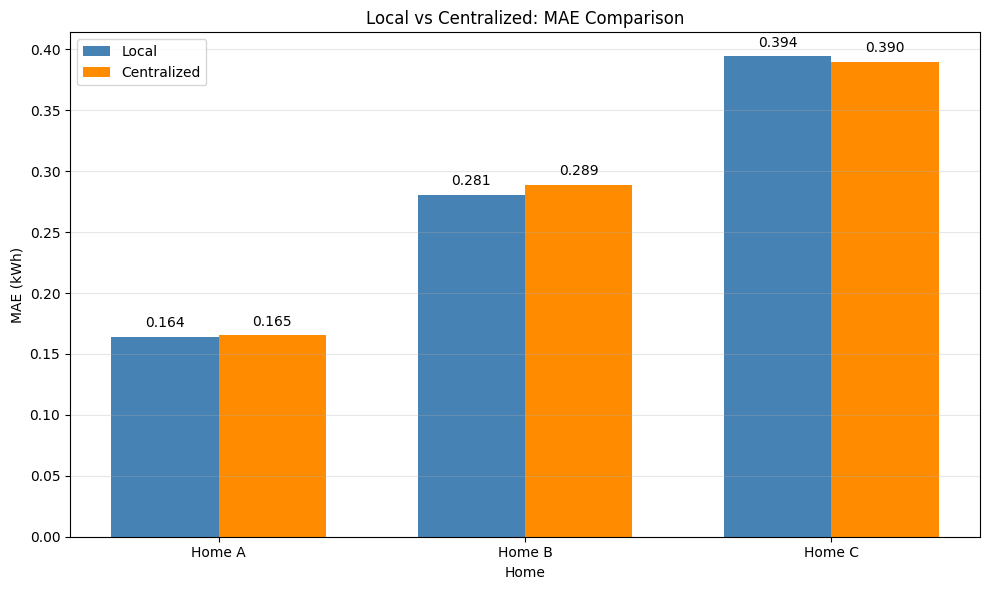


✅ Comparison complete!


In [9]:
# 04_virtual_homes.py
# ─────────────────────────────────────────────
# Compares three training approaches:
# 1. Local: Each home trains its own model
# 2. Centralized: All data pooled, one model
# 3. Federated: (Placeholder — done in Part 6)
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

FEATURES = [
    'lag_1',
    'lag_4',
    'lag_96',
    'rolling_mean_4',
    'rolling_mean_96',
    'rolling_std_4',
    'hour',
    'day_of_week',
    'is_weekend',
    'month'
]
TARGET = 'consumption_kwh'

def load_split(filepath):
    """Load CSV and return train/test splits."""
    df = pd.read_csv(filepath, parse_dates=['timestamp'])
    df = df.dropna()
    X = df[FEATURES].values
    y = df[TARGET].values
    split = int(len(X) * 0.8)
    return X[:split], X[split:], y[:split], y[split:]

def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    return {
        'mae': mean_absolute_error(y_test, preds),
        'rmse': np.sqrt(mean_squared_error(y_test, preds)),
    }

def train_rf(X_train, y_train):
    m = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    return m

# ── Load data ──────────────────────────────────
print("Loading data...")
Xa_tr, Xa_te, ya_tr, ya_te = load_split('homes/home_a.csv')
Xb_tr, Xb_te, yb_tr, yb_te = load_split('homes/home_b.csv')
Xc_tr, Xc_te, yc_tr, yc_te = load_split('homes/home_c.csv')

# ── Approach 1: Local models ───────────────────
print("\nApproach 1: Local models (each home trains alone)")
model_a = train_rf(Xa_tr, ya_tr)
model_b = train_rf(Xb_tr, yb_tr)
model_c = train_rf(Xc_tr, yc_tr)

local_results = {
    'Home A (local)': evaluate(model_a, Xa_te, ya_te),
    'Home B (local)': evaluate(model_b, Xb_te, yb_te),
    'Home C (local)': evaluate(model_c, Xc_te, yc_te),
}

# ── Approach 2: Centralized ────────────────────
print("Approach 2: Centralized (all data combined)")
X_all_tr = np.vstack([Xa_tr, Xb_tr, Xc_tr])
y_all_tr = np.concatenate([ya_tr, yb_tr, yc_tr])
central_model = train_rf(X_all_tr, y_all_tr)

centralized_results = {
    'Home A (central)': evaluate(central_model, Xa_te, ya_te),
    'Home B (central)': evaluate(central_model, Xb_te, yb_te),
    'Home C (central)': evaluate(central_model, Xc_te, yc_te),
}

# ── Print comparison ───────────────────────────
print("\n" + "="*65)
print("COMPARISON: LOCAL vs CENTRALIZED")
print("="*65)
print(f"{'Setup':<25} {'MAE':>10} {'RMSE':>10}")
print("-"*65)
for label, r in {**local_results, **centralized_results}.items():
    print(f"{label:<25} {r['mae']:>10.4f} {r['rmse']:>10.4f}")

# ── Visualize ──────────────────────────────────
homes = ['Home A', 'Home B', 'Home C']
local_maes = [local_results[f'{h} (local)']['mae'] for h in homes]
central_maes = [centralized_results[f'{h} (central)']['mae'] for h in homes]

x = np.arange(len(homes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, local_maes, width, label='Local', color='steelblue')
bars2 = ax.bar(x + width/2, central_maes, width, label='Centralized', color='darkorange')

ax.set_xlabel('Home')
ax.set_ylabel('MAE (kWh)')
ax.set_title('Local vs Centralized: MAE Comparison')
ax.set_xticks(x)
ax.set_xticklabels(homes)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('local_vs_centralized.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Comparison complete!")

Federated Learning — Manual FedAvg Implementation

Step 1: Initializing global model...

FEDERATED LEARNING — Running Rounds

--- Round 1/5 ---
  Broadcasting global model...
  Local training:
  Home A: Local MAE = 0.1683
  Home B: Local MAE = 0.2876
  Home C: Local MAE = 0.3981
  Aggregating:
  → Global MAE: 0.2857

--- Round 2/5 ---
  Broadcasting global model...
  Local training:
  Home A: Local MAE = 0.1933
  Home B: Local MAE = 0.3731
  Home C: Local MAE = 0.4098
  Aggregating:
  → Global MAE: 0.1888

--- Round 3/5 ---
  Broadcasting global model...
  Local training:
  Home A: Local MAE = 0.1747
  Home B: Local MAE = 0.3650
  Home C: Local MAE = 0.4028
  Aggregating:
  → Global MAE: 0.1617

--- Round 4/5 ---
  Broadcasting global model...
  Local training:
  Home A: Local MAE = 0.1710
  Home B: Local MAE = 0.3771
  Home C: Local MAE = 0.4026
  Aggregating:
  → Global MAE: 0.1689

--- Round 5/5 ---
  Broadcasting global model...
  Local training:
  Home A: Local MAE = 0.1716
  Home

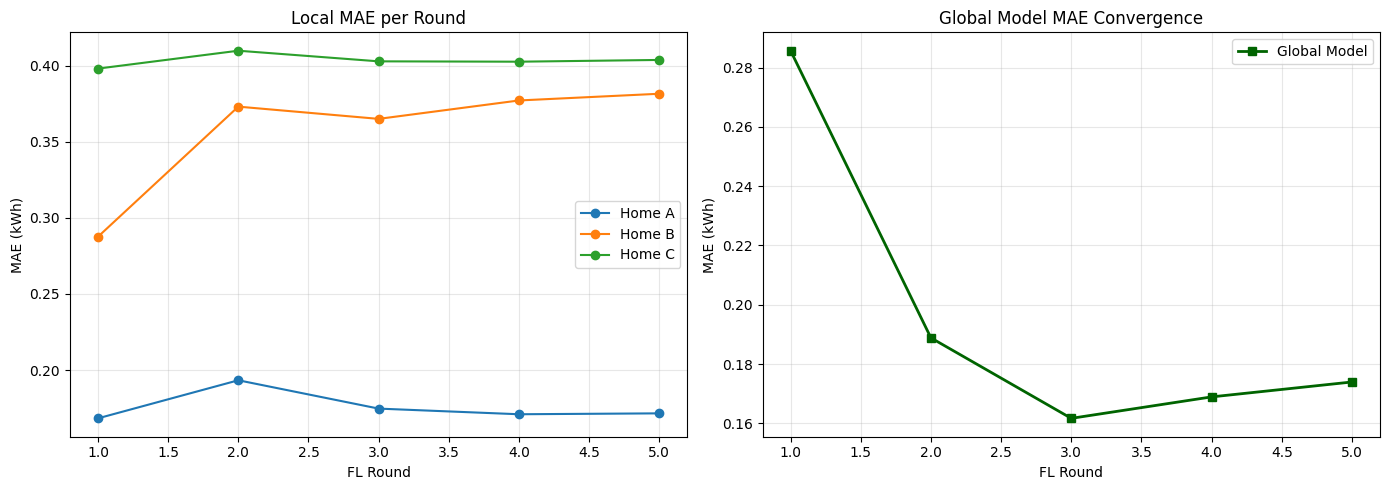


✅ Federated Learning complete!


In [10]:
# 05_federated_learning.py (Part 1: Manual FedAvg)
# ─────────────────────────────────────────────
# Manual implementation of Federated Learning
# WITHOUT using Flower library.
# This teaches you exactly what FL does step by step.
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

FEATURES = [
    'lag_1',
    'lag_4',
    'lag_96',
    'rolling_mean_4',
    'rolling_mean_96',
    'rolling_std_4',
    'hour',
    'day_of_week',
    'is_weekend',
    'month'
]
TARGET = 'consumption_kwh'

# ── CRITICAL CONCEPT: Model Weights ───────────
# For traditional ML (not deep learning), we can't
# average the weights directly like in neural networks.
# Instead, we use a practical approach:
#
## Strategy 1 (Simple): Train on combined pseudo-data
# - Each home sends a SAMPLE of its predictions
# - Server trains on combined samples
# - This simulates the spirit of federated averaging
#
## Strategy 2 (Proper for sklearn): Vote/ensemble
# - Keep all local models
# - Global prediction = weighted average of all models

print("Federated Learning — Manual FedAvg Implementation")
print("="*55)

# ── Load data ──────────────────────────────────
def load_data(path):
    df = pd.read_csv(path).dropna()
    X = df[FEATURES].values
    y = df[TARGET].values
    split = int(len(X) * 0.8)
    return X[:split], X[split:], y[:split], y[split:]

Xa_tr, Xa_te, ya_tr, ya_te = load_data('homes/home_a.csv')
Xb_tr, Xb_te, yb_tr, yb_te = load_data('homes/home_b.csv')
Xc_tr, Xc_te, yc_tr, yc_te = load_data('homes/home_c.csv')

# ── Step 1: Initialize global "knowledge" ────────
# In the first round, we create a base model
# from a small combined sample.
print("\nStep 1: Initializing global model...")

# Take a small random sample from each home
# (simulating only summary info being shared)
sample_size = 200
Xa_sample = Xa_tr[:sample_size]
ya_sample = ya_tr[:sample_size]
Xb_sample = Xb_tr[:sample_size]
yb_sample = yb_tr[:sample_size]
Xc_sample = Xc_tr[:sample_size]
yc_sample = yc_tr[:sample_size]

# ── Step 2: Federated Rounds ──────────────────
class FederatedClient:
    """Represents one FL client (one home)."""
    def __init__(self, name, X_train, y_train, X_test, y_test):
        self.name = name
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.model = None
        self.history = []  # Track MAE over rounds

    def local_train(self, global_params=None, n_trees=50):
        """
        Train locally.
        global_params: If provided, we use global model as starting point.
        """
        # In sklearn, we can't truly "resume" training from global weights.
        # We simulate this by:
        # 1. If global_params provided: use global model predictions as
        #    "pseudo-labels" and train on augmented dataset.
        # 2. This mimics the warming effect of FL.
        if global_params is not None and 'model' in global_params:
            # Use global model to generate pseudo-predictions
            global_preds = global_params['model'].predict(self.X_train)
            # Mix local labels with global predictions (70% local, 30% global)
            y_mixed = 0.7 * self.y_train + 0.3 * global_preds
        else:
            y_mixed = self.y_train

        self.model = RandomForestRegressor(
            n_estimators=n_trees,
            max_depth=8,
            random_state=42,
            n_jobs=-1
        )
        self.model.fit(self.X_train, y_mixed)

        # Evaluate locally
        preds = self.model.predict(self.X_test)
        mae = mean_absolute_error(self.y_test, preds)
        self.history.append(mae)
        print(f"  {self.name}: Local MAE = {mae:.4f}")
        return self.model

    def get_predictions_sample(self, X_sample):
        """Return model predictions on a shared sample."""
        return self.model.predict(X_sample)

class FederatedServer:
    """The central server that aggregates client updates."""
    def __init__(self, clients):
        self.clients = clients
        self.global_model = None
        self.round_maes = []  # Track global performance

        # Create a shared evaluation set (from first client, not training data)
        self.X_eval = clients[0].X_test[:100]
        self.y_eval = clients[0].y_test[:100]

    def aggregate(self, shared_X, shared_y):
        """
        FedAvg: Train global model on averaged client outputs.

        In practice with sklearn:
        - Collect predictions from all clients on a shared dataset
        - Average those predictions
        - Train a new global model on (features, averaged_predictions)
        """
        # Get predictions from each client
        all_predictions = np.array([
            client.get_predictions_sample(shared_X) for client in self.clients
        ])
        # Average across clients (this IS FedAvg for predictions)
        averaged_predictions = all_predictions.mean(axis=0)

        # Train global model on averaged predictions
        self.global_model = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
        self.global_model.fit(shared_X, averaged_predictions)

        # Evaluate global model
        global_preds = self.global_model.predict(self.X_eval)
        global_mae = mean_absolute_error(self.y_eval, global_preds)
        self.round_maes.append(global_mae)
        print(f"  → Global MAE: {global_mae:.4f}")
        return self.global_model

# ── Create clients ─────────────────────────────
clients = [
    FederatedClient('Home A', Xa_tr, ya_tr, Xa_te, ya_te),
    FederatedClient('Home B', Xb_tr, yb_tr, Xb_te, yb_te),
    FederatedClient('Home C', Xc_tr, yc_tr, Xc_te, yc_te),
]
server = FederatedServer(clients)

# Shared evaluation dataset (public, doesn't contain private data)
# In real FL, this is a small public dataset used for aggregation
X_shared = np.vstack([Xa_sample, Xb_sample, Xc_sample])
y_shared = np.concatenate([ya_sample, yb_sample, yc_sample])

# ── Run Federated Learning Rounds ─────────────
N_ROUNDS = 5
global_params = None

print("\n" + "="*55)
print("FEDERATED LEARNING — Running Rounds")
print("="*55)
for round_num in range(1, N_ROUNDS + 1):
    print(f"\n--- Round {round_num}/{N_ROUNDS} ---")
    # Step 1: Distribute global model to all clients
    print("  Broadcasting global model...")

    # Step 2: Each client trains locally
    print("  Local training:")
    for client in clients:
        client.local_train(global_params=global_params, n_trees=50)

    # Step 3: Server aggregates
    print("  Aggregating:")
    global_model = server.aggregate(X_shared, y_shared)
    global_params = {'model': global_model}

# ── Final evaluation ───────────────────────────
print("\n" + "="*55)
print("FINAL RESULTS")
print("="*55)

def final_eval(model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return mae, rmse

print(f"\n{'Approach':<25} {'MAE':>10} {'RMSE':>10}")
print("-"*50)

for client in clients:
    mae, rmse = final_eval(client.model, client.X_test, client.y_test)
    print(f"{client.name + ' (local)':<25} {mae:>10.4f} {rmse:>10.4f}")

# Global model evaluation on each home
for client in clients:
    mae, rmse = final_eval(global_model, client.X_test, client.y_test)
    print(f"{client.name + ' (federated)':<25} {mae:>10.4f} {rmse:>10.4f}")

# ── Visualize convergence ──────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
rounds = list(range(1, N_ROUNDS + 1))

for client in clients:
    ax1.plot(rounds, client.history, marker='o', label=client.name)
ax1.set_title('Local MAE per Round')
ax1.set_xlabel('FL Round')
ax1.set_ylabel('MAE (kWh)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(rounds, server.round_maes, marker='s', color='darkgreen', linewidth=2, label='Global Model')
ax2.set_title('Global Model MAE Convergence')
ax2.set_xlabel('FL Round')
ax2.set_ylabel('MAE (kWh)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('federated_learning.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Federated Learning complete!")

In [12]:
# 06_shap_explainability.py
# ─────────────────────────────────────────────
# Explains model predictions using SHAP.
# Makes the "black box" transparent.
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle

FEATURES = [
    'lag_1',
    'lag_4',
    'lag_96',
    'rolling_mean_4',
    'rolling_mean_96',
    'rolling_std_4',
    'hour',
    'day_of_week',
    'is_weekend',
    'month'
]
TARGET = 'consumption_kwh'

def explain_model(home_name, model_path, data_path):
    """Generate SHAP explanations for one home's model."""
    print(f"\n{'='*50}")
    print(f"SHAP Explanation: {home_name}")
    print('='*50)

    # Load model and data
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    df = pd.read_csv(data_path).dropna()
    X = pd.DataFrame(df[FEATURES].values, columns=FEATURES)
    y = df[TARGET].values

    # ── Create SHAP Explainer ──────────────────
    # TreeExplainer is optimized for tree-based models
    # (Random Forest, XGBoost, etc.)
    print("Creating SHAP explainer...")
    explainer = shap.TreeExplainer(model)

    # ── Calculate SHAP values ──────────────────
    # Use a sample for speed — full dataset takes too long
    sample_size = 500
    X_sample = X.iloc[:sample_size]
    print(f"Calculating SHAP values for {sample_size} samples...")
    shap_values = explainer.shap_values(X_sample)
    # Shape: (n_samples, n_features) — one SHAP value per feature per sample
    print(f"SHAP values shape: {shap_values.shape}")

    # ── Global Feature Importance ──────────────
    # Mean absolute SHAP value per feature
    mean_shap = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        'feature': FEATURES,
        'importance': mean_shap,
    }).sort_values('importance', ascending=False)

    print(f"\nGlobal Feature Importance (SHAP):")
    for _, row in importance_df.iterrows():
        bar = '█' * int(row['importance'] / mean_shap.max() * 30)
        print(f"  {row['feature']:25s} {bar:30s} {row['importance']:.4f}")

    # ── Explain ONE specific prediction ───────
    # Pick a sample to explain in detail
    sample_idx = 100 # 101st data point
    sample_X = X_sample.iloc[[sample_idx]]
    prediction = model.predict(sample_X)[0]
    base_value = explainer.expected_value

    print(f"\nDetailed explanation for sample {sample_idx}:")
    # Convert base_value to a scalar if it's a numpy array
    if isinstance(base_value, np.ndarray):
        base_value = base_value.item()
    print(f"  Base value (average prediction): {base_value:.4f} kWh")
    print(f"  Actual prediction: {prediction:.4f} kWh")
    print(f"  Difference from base: {prediction - base_value:+.4f} kWh")

    print(f"\n  Feature contributions:")
    sample_shap = shap_values[sample_idx]
    feature_contributions = list(zip(FEATURES, sample_shap, sample_X.values[0]))
    feature_contributions.sort(key=lambda x: abs(x[1]), reverse=True)

    for feat, shap_val, feat_val in feature_contributions:
        direction = '+' if shap_val > 0 else '-'
        bar = '█' * int(abs(shap_val) / max(abs(s) for _,s,_ in feature_contributions) * 20)
        print(f"  {feat:25s} value={feat_val:6.2f} SHAP={shap_val:+.4f} {bar}")

    # ── Visualize ──────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Plot 1: Summary bar plot (global importance)
    ax = axes[0]
    colors = ['#2E75B6' if v > 0 else '#C0392B' for v in importance_df['importance']]
    ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'{home_name} — Feature Importance (SHAP)')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')

    # Plot 2: Waterfall for one prediction
    ax = axes[1]
    sorted_feats = [fc[0] for fc in feature_contributions]
    sorted_shaps = [fc[1] for fc in feature_contributions]
    bar_colors = ['forestgreen' if s > 0 else 'crimson' for s in sorted_shaps]
    ax.barh(sorted_feats, sorted_shaps, color=bar_colors)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value (impact on prediction)')
    ax.set_title(f'{home_name} — Single Prediction Explanation')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig(f'shap_{home_name.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.close()

    return {
        'top_feature': importance_df.iloc[0]['feature'],
        'prediction': prediction,
        'base_value': base_value,
        'shap_values': shap_values,
        'feature_contributions': feature_contributions,
    }

# ── Run SHAP for all homes ─────────────────────
for name, model_p, data_p in [
    ('Home A', 'models/model_a.pkl', 'homes/home_a.csv'),
    ('Home B', 'models/model_b.pkl', 'homes/home_b.csv'),
    ('Home C', 'models/model_c.pkl', 'homes/home_c.csv'),
]:
    explain_model(name, model_p, data_p)

print("\n✅ SHAP explanation complete!")


SHAP Explanation: Home A
Creating SHAP explainer...
Calculating SHAP values for 500 samples...
SHAP values shape: (500, 10)

Global Feature Importance (SHAP):
  rolling_mean_4            ██████████████████████████████ 0.6963
  hour                      ██████                         0.1594
  lag_96                    █████                          0.1378
  lag_1                     ███                            0.0752
  rolling_std_4             █                              0.0254
  lag_4                                                    0.0143
  rolling_mean_96                                          0.0070
  day_of_week                                              0.0026
  is_weekend                                               0.0014
  month                                                    0.0005

Detailed explanation for sample 100:
  Base value (average prediction): 1.5741 kWh
  Actual prediction: 0.7241 kWh
  Difference from base: -0.8500 kWh

  Feature contributions:
  

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(



SHAP Explanation: Home B
Creating SHAP explainer...
Calculating SHAP values for 500 samples...
SHAP values shape: (500, 10)

Global Feature Importance (SHAP):
  rolling_mean_4            ██████████████████████████████ 1.4212
  hour                      ██████                         0.3145
  lag_1                     █████                          0.2419
  lag_4                     ██                             0.1122
  lag_96                    █                              0.0498
  rolling_std_4                                            0.0336
  rolling_mean_96                                          0.0081
  day_of_week                                              0.0033
  is_weekend                                               0.0028
  month                                                    0.0021

Detailed explanation for sample 100:
  Base value (average prediction): 3.6166 kWh
  Actual prediction: 2.0893 kWh
  Difference from base: -1.5273 kWh

  Feature contributions:
  

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(



SHAP Explanation: Home C
Creating SHAP explainer...
Calculating SHAP values for 500 samples...
SHAP values shape: (500, 10)

Global Feature Importance (SHAP):
  rolling_mean_4            ██████████████████████████████ 0.8413
  lag_1                     ████                           0.1401
  hour                      ██                             0.0574
  rolling_std_4             █                              0.0338
  lag_96                    █                              0.0334
  lag_4                     █                              0.0282
  rolling_mean_96                                          0.0072
  day_of_week                                              0.0027
  month                                                    0.0009
  is_weekend                                               0.0006

Detailed explanation for sample 100:
  Base value (average prediction): 2.0924 kWh
  Actual prediction: 0.6007 kWh
  Difference from base: -1.4917 kWh

  Feature contributions:
  

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(



✅ SHAP explanation complete!


In [18]:
# 07_energy_agent.py
# ─────────────────────────────────────────────
# Rule-based Energy Agent that:
# 1. Takes forecasts and anomaly scores as input
# 2. Reasons about the situation
# 3. Outputs recommendations
# ─────────────────────────────────────────────

import pickle
import pandas as pd
import numpy as np
import shap

FEATURES = [
    'lag_1',
    'lag_4',
    'lag_96',
    'rolling_mean_4',
    'rolling_mean_96',
    'rolling_std_4',
    'hour',
    'day_of_week',
    'is_weekend',
    'month'
]

class EnergyAgent:
    """
    A rule-based agent for smart home energy management.
    This is intentionally simple — in GridGuard, this would be replaced by a more
    sophisticated LLM-based agent.
    But the ARCHITECTURE (observe → reason → act) is the same.
    """
    def __init__(self, home_id, model_path, anomaly_model_path=None):
        self.home_id = home_id

        # Load forecasting model
        with open(model_path, 'rb') as f:
            self.forecast_model = pickle.load(f)

        # Create SHAP explainer
        self.explainer = shap.TreeExplainer(self.forecast_model)

        # Thresholds for decision making
        self.ANOMALY_THRESHOLD_LOW = 0.5
        self.ANOMALY_THRESHOLD_HIGH = 0.75
        self.FORECAST_HIGH_THRESHOLD = 3.5 # kWh
        self.FORECAST_VERY_HIGH = 5.0 # kWh

        print(f"Energy Agent initialized for {home_id}")

    def observe(self, features_dict):
        """ OBSERVE: Gather current state.
        Takes a dictionary of feature values and returns a structured observation.
        """
        features_df = pd.DataFrame([features_dict])
        X = features_df[FEATURES].values

        # Get prediction
        prediction = self.forecast_model.predict(X)[0]

        # Get SHAP explanation
        shap_values = self.explainer.shap_values(X)[0]
        feature_impacts = sorted(
            zip(FEATURES, shap_values),
            key=lambda x: abs(x[1]),
            reverse=True
        )

        observation = {
            'home_id': self.home_id,
            'predicted_kwh': round(prediction, 3),
            'top_features': feature_impacts[:3],
            'raw_features': features_dict,
        }
        return observation

    def reason(self, observation, anomaly_score):
        """ REASON: Analyze the observation and determine severity.
        Returns a structured analysis with:
        - severity level
        - detected conditions
        - reasoning explanation
        """
        pred = observation['predicted_kwh']
        conditions = []
        reasoning = []

        # ── Check anomaly ──────────────────────
        if anomaly_score > self.ANOMALY_THRESHOLD_HIGH:
            conditions.append('HIGH_ANOMALY')
            reasoning.append(f"Anomaly score {anomaly_score:.2f} exceeds high threshold.")
        elif anomaly_score > self.ANOMALY_THRESHOLD_LOW:
            conditions.append('MODERATE_ANOMALY')
            reasoning.append(f"Anomaly score {anomaly_score:.2f} is moderately elevated.")

        # ── Check forecast ─────────────────────
        if pred > self.FORECAST_VERY_HIGH:
            conditions.append('VERY_HIGH_FORECAST')
            reasoning.append(f"Predicted {pred:.2f} kWh far exceeds normal range.")
        elif pred > self.FORECAST_HIGH_THRESHOLD:
            conditions.append('HIGH_FORECAST')
            reasoning.append(f"Predicted {pred:.2f} kWh is above normal range.")

        # ── Check feature explanations ─────────
        for feat, shap_val in observation['top_features']:
            if feat == 'lag_1' and shap_val > 0.5:
                conditions.append('RECENT_SURGE')
                reasoning.append("Recent consumption spike detected.")
                break

        # ── Determine severity ─────────────────
        if 'HIGH_ANOMALY' in conditions or 'VERY_HIGH_FORECAST' in conditions:
            severity = 'CRITICAL'
        elif 'MODERATE_ANOMALY' in conditions or 'HIGH_FORECAST' in conditions:
            severity = 'WARNING'
        elif 'RECENT_SURGE' in conditions:
            severity = 'ADVISORY'
        else:
            severity = 'NORMAL'

        return {
            'severity': severity,
            'conditions': conditions,
            'reasoning': reasoning,
        }

    def act(self, observation, analysis):
        """ ACT: Generate a concrete recommendation.
        Maps severity + conditions → actionable recommendation.
        """
        severity = analysis['severity']
        conditions = analysis['conditions']
        pred = observation['predicted_kwh']

        # ── Generate recommendation ────────────
        if severity == 'CRITICAL':
            if 'HIGH_ANOMALY' in conditions and 'VERY_HIGH_FORECAST' in conditions:
                action = "IMMEDIATE INSPECTION REQUIRED"
                message = (
                    f"Critical energy anomaly detected at {self.home_id}. "
                    f"Predicted consumption ({pred:.2f} kWh) is extremely high. "
                    "Check for faulty appliances, meter tampering, or unusual activity. "
                    "Consider temporarily reducing load."
                )
            elif 'HIGH_ANOMALY' in conditions:
                action = "INVESTIGATE IMMEDIATELY"
                message = (
                    f"High anomaly score at {self.home_id}. "
                    "Current consumption pattern is highly unusual. "
                    "Check all high-draw appliances."
                )
            else:
                action = "REDUCE LOAD"
                message = (
                    f"Very high consumption predicted ({pred:.2f} kWh) at {self.home_id}. "
                    "Consider deferring high-energy tasks."
                )
        elif severity == 'WARNING':
            action = "MONITOR CLOSELY"
            message = (
                f"Elevated energy usage at {self.home_id} "
                f"(predicted: {pred:.2f} kWh). "
                "Review active appliances and consider load scheduling."
            )
        elif severity == 'ADVISORY':
            action = "ADVISORY"
            message = (
                f"Recent consumption surge detected at {self.home_id}. "
                "Monitor for continued high usage."
            )
        else:
            action = "NORMAL — NO ACTION REQUIRED"
            message = (
                f"{self.home_id} operating normally. "
                f"Predicted consumption: {pred:.2f} kWh."
            )

        return {
            'home_id': self.home_id,
            'severity': severity,
            'action': action,
            'message': message,
            'prediction': pred,
        }

    def run(self, features_dict, anomaly_score):
        """ Full agent cycle: Observe → Reason → Act.
        Returns the complete recommendation.
        """
        observation = self.observe(features_dict)
        analysis = self.reason(observation, anomaly_score)
        decision = self.act(observation, analysis)
        return decision

# ── Demo: Run the agent ────────────────────────
if __name__ == '__main__':
    # Load one home's data to get a real feature sample
    df = pd.read_csv('homes/home_a.csv').dropna()

    print("="*60)
    print("ENERGY AGENT DEMONSTRATION")
    print("="*60)

    agent_a = EnergyAgent('Home A', 'models/model_a.pkl')

    # Test 1: Normal situation
    print("\n--- Test 1: Normal Consumption ---")
    normal_sample = df[FEATURES].iloc[500].to_dict()
    result = agent_a.run(normal_sample, anomaly_score=0.2)
    print(f"  Severity: {result['severity']}")
    print(f"  Action: {result['action']}")
    print(f"  Message: {result['message']}")

    # Test 2: High anomaly
    print("\n--- Test 2: High Anomaly Detected ---")
    anomaly_sample = df[FEATURES].iloc[500].to_dict()
    # Simulate high recent consumption
    anomaly_sample['lag_1'] = 9.5
    anomaly_sample['rolling_mean_4'] = 7.2
    result = agent_a.run(anomaly_sample, anomaly_score=0.85)
    print(f"  Severity: {result['severity']}")
    print(f"  Action: {result['action']}")
    print(f"  Message: {result['message']}")

    print("\n✅ Agent demonstration complete!")

ENERGY AGENT DEMONSTRATION
Energy Agent initialized for Home A

--- Test 1: Normal Consumption ---
  Severity: NORMAL
  Action: NORMAL — NO ACTION REQUIRED
  Message: Home A operating normally. Predicted consumption: 0.96 kWh.

--- Test 2: High Anomaly Detected ---
  Severity: CRITICAL
  Action: IMMEDIATE INSPECTION REQUIRED
  Message: Critical energy anomaly detected at Home A. Predicted consumption (7.11 kWh) is extremely high. Check for faulty appliances, meter tampering, or unusual activity. Consider temporarily reducing load.

✅ Agent demonstration complete!
